# Marketplace matching

A small batch of job descriptions goes through structured representation, vector retrieval, performance scoring, and allocation.

The default uses stored jobs and embeddings. Set `USE_CUSTOM_JDS = True` to use your own descriptions. Candidate profiles and performance labels in this demo are synthetic; predicted scores are not measured hiring outcomes.

In [1]:
from pathlib import Path
import sys
import os
import json
import time

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "matching-pipeline").is_dir())
for directory in [
    "retrieval/src", "retrieval/scripts", "modeling/src",
    "allocation/src", "allocation/scripts",
]:
    sys.path.insert(0, str(ROOT / "matching-pipeline" / directory))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display, Markdown
from dotenv import load_dotenv

from retrieval.schemas import JobProfile
from retrieval.renderers import render_job
from retrieval.embeddings import embedding_matrix
from retrieval.exact_search import exact_cosine_search
from modeling.features import BASE_FEATURE_COLUMNS
from modeling.reranker import rerank_candidates
from allocation.optimizer import greedy_allocate, optimize_allocation
from allocation.scenarios import select_similar_jobs, has_required_certifications
from simulate_cold_start import full_pool_capacity

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 85)
DATA = ROOT / "ground-truth-generation/data/v1"
RETRIEVAL = ROOT / "matching-pipeline/retrieval"
MODELING = ROOT / "matching-pipeline/modeling"

## 1. Jobs and candidate pool

The stored example selects similar jobs by role profile and embedding similarity. Selection does not use performance scores or outcomes.

In [2]:
USE_CUSTOM_JDS = False
RETRIEVAL_BACKEND = "exact"  # "hnsw" uses the existing pgvector database
DEMO_JOB_COUNT = 10
INITIAL_K = 50

JOB_DESCRIPTIONS = [
    """Senior Machine Learning Engineer. Build ranking and recommendation systems
    using Python, PyTorch, SQL, AWS and Kubernetes. Five years of experience required.""",
    """Machine Learning Platform Engineer. Own model deployment, feature pipelines,
    monitoring, Python services, Docker, Kubernetes and cloud infrastructure.""",
    """Applied ML Engineer. Develop NLP models and retrieval systems, evaluate
    quality, and ship Python services with data and product teams.""",
]

jobs = pd.read_parquet(DATA / "jobs.parquet")
candidates = pd.read_parquet(DATA / "candidates.parquet")
assessments = pd.read_parquet(DATA / "candidate_assessments.parquet")
candidate_vectors = pd.read_parquet(RETRIEVAL / "artifacts/embeddings/candidates.parquet")
candidate_vectors = candidate_vectors.sort_values("entity_id").reset_index(drop=True)
stored_vectors = pd.read_parquet(RETRIEVAL / "artifacts/embeddings/jobs.parquet")
model = joblib.load(MODELING / "artifacts/model/performance_model.joblib")

if not USE_CUSTOM_JDS:
    selected_jobs = select_similar_jobs(jobs, stored_vectors, DEMO_JOB_COUNT)
    descriptions = selected_jobs.description.tolist()
else:
    descriptions = JOB_DESCRIPTIONS
    if not descriptions or any(not text.strip() for text in descriptions):
        raise ValueError("Provide nonempty job descriptions.")

print(f"Candidate pool: {len(candidate_vectors):,} | Input jobs: {len(descriptions)}")
for number, description in enumerate(descriptions, 1):
    display(Markdown(f"**J{number}**"))
    print(description[:600] + (" …" if len(description) > 600 else ""))
display(candidates[["candidate_id", "current_title", "skills", "years_experience"]].head(3))

Candidate pool: 5,000 | Input jobs: 10


**J1**

Title: PRN Registered Nurse State Role Title: 49113 Hiring Range: $45.32 + 2nd/3rd shift differentials/holidays differentials/weekend differentials Pay Band: 5 Agency: Dept Behavioral Health/Develop Location: Southern Va Mental Health Inst Agency Website: https://dbhds.virginia.gov/facilities/svmhi/ Recruitment Type: General Public - G Job Duties This is an entry level position for Registered Nurses (RN) who are new graduates or have minimal RN experience. This is a PRN position (up to 28 hours/week) with no benefits. The Department of Behavioral Health and Developmental services support indiv …


**J2**

Title: Registered Nurse I (Nights) State Role Title: 49112 Hiring Range: $74,572 minimum, negotiable, based on relevant years of experience Pay Band: 4 Agency: Dept Behavioral Health/Develop Location: Southern Va Mental Health Inst Agency Website: https://www.svmhi.dbhds.virginia.gov/ Recruitment Type: General Public - G Job Duties Come Join our team of Registered Nurses that makes a difference! Up to a $25,000 Bonus for Registered Nurses that are new to state service and remain with the facility for 2 years. $15,000 sign on bonus will be awarded to new hires to state service with a one-year w …


...

**J9**

THE POSITION NOTE: THIS IS A REPOSTING OF CS-2024-77979-30431. IF YOU APPLIED UNDER THE PREVIOUS POSTING WHICH WAS OPEN FROM MARCH 6, 2024 TO MARCH 22, 2024, YOU CANNOT SUBMIT A NEW APPLICATION. Are you a dependable, compassionate, and hardworking Certified Registered Nurse Practitioner (CRNP) who is looking for a wonderful opportunity to work in a top-notch facility? The Department of Human Services, Warren State Hospital is looking for someone interested in providing psychiatric behavioral/mental health treatment of individuals with severe and persistent mental illness at an inpatient psychi …


**J10**

Adventist Rehabilitation - Rockville If you are a current Adventist HealthCare employee, please click this link to apply through your Workday account. Adventist HealthCare Rehabilitation seeks to hire an experienced Registered Nurse for our Rehabilitation Department who will embrace our mission to extend God’s care through the ministry of physical, mental, and spiritual healing. As a Rehabilitation Registered Nurse, You Will Assessment, planning, intervention & evaluation of patient care at the beside. Documentation (electronic) of patient care and outcomes. Delegation of tasks to non-licensed …


,candidate_id,current_title,skills,years_experience
0,syn_v1_000001,Help Desk Technician,"[Ticket management, Mobile device support, Microsoft 365, Computer hardware]",1
1,syn_v1_000002,Technical Support Specialist,"[Knowledge base documentation, Remote support, Active Directory, Epic support, Pe...",2
2,syn_v1_000003,Enterprise Project Manager,"[change management, business process analysis, steering committee reporting, budg...",7


## 2. Structured jobs and embeddings

Custom descriptions are extracted into fields used by both retrieval and scoring. Stored mode reuses existing structured fields and cached embeddings. Both sides must use the same embedding model and dimension.

In [3]:
embedding_models = candidate_vectors.model.unique()
embedding_dimensions = candidate_vectors.dimensions.unique()
assert len(embedding_models) == len(embedding_dimensions) == 1
embedding_model = str(embedding_models[0])
dimension = int(embedding_dimensions[0])

if USE_CUSTOM_JDS:
    from openai import OpenAI
    from retrieval.job_extraction import extract_job_profiles
    load_dotenv(ROOT / ".env")
    client = OpenAI(timeout=60.0, max_retries=2)
    role_options = jobs[["role_family", "role_type", "role_track"]].drop_duplicates().to_dict("records")
    profiles = extract_job_profiles(
        descriptions, role_options, client,
        model=os.getenv("OPENAI_EXTRACTION_MODEL", "gpt-5.6-luna"),
    )
    selected_jobs = pd.DataFrame([profile.model_dump() for profile in profiles])
    response = client.embeddings.create(
        model=embedding_model, dimensions=dimension,
        input=[render_job(profile) for profile in profiles],
    )
    job_matrix = np.asarray([item.embedding for item in sorted(response.data, key=lambda item: item.index)],
                            dtype=np.float32)
else:
    profiles = [JobProfile.from_row(row) for row in selected_jobs.to_dict("records")]
    selected_vectors = stored_vectors.set_index("entity_id").loc[selected_jobs.job_id]
    assert set(selected_vectors.model) == {embedding_model}
    assert set(selected_vectors.dimensions) == {dimension}
    job_matrix = embedding_matrix(selected_vectors)

labels = dict(zip(selected_jobs.job_id, [f"J{i+1}" for i in range(len(selected_jobs))]))
display(selected_jobs[["job_id", "title", "role_track", "seniority",
                       "required_skills", "required_certifications"]])
print(f"Embedding model: {embedding_model} | Dimensions: {dimension}")
print("\nRepresentation of the first job:\n")
print(render_job(profiles[0])[:1200])

,job_id,title,role_track,seniority,required_skills,required_certifications
0,3884426762,PRN Registered Nurse,Post-Acute and Long-Term Care Registered Nursing,senior,[infection prevention],[]
1,3901937580,Registered Nurse I (Nights),Post-Acute and Long-Term Care Registered Nursing,senior,[infection prevention],[]
2,3891074610,Team Nurse - Agency Only,Post-Acute and Long-Term Care Registered Nursing,senior,[],[]
3,3905261467,Licensed Practical Nurse - Primary Care PACT - UP TO 10k SIGN ON BONUS,Post-Acute and Long-Term Care Registered Nursing,senior,[medication administration],[BLS certification]
4,3889279489,Licensed Practical Nurse (LPN),Post-Acute and Long-Term Care Registered Nursing,senior,[medication administration],[]
5,3904719931,"Assistant Nurse Manager, Day Shift, Rehabilitation",Post-Acute and Long-Term Care Registered Nursing,senior,[],[BLS certification]
6,3902358712,Nurse (SANE) - Outpatient,Post-Acute and Long-Term Care Registered Nursing,senior,[],[]
7,3900955065,REGISTERED NURSE - **La Selva Residential**,Post-Acute and Long-Term Care Registered Nursing,senior,[],[]
8,3889290143,Certified Registered Nurse Practitioner - Warren State Hospital,Post-Acute and Long-Term Care Registered Nursing,senior,[],[]
9,3903843291,"Registered Nurse (RN), Night Shift, Acute-Care Rehab",Post-Acute and Long-Term Care Registered Nursing,senior,[],[BLS certification]


Embedding model: text-embedding-3-small | Dimensions: 1536

Representation of the first job:

Title: PRN Registered Nurse
Role: Healthcare | Nursing | Post-Acute and Long-Term Care Registered Nursing
Seniority: senior
Minimum experience: Unknown
Required skills: infection prevention
Preferred skills: Unknown
Domain: healthcare
Required certifications: Unknown
Description: Title: PRN Registered Nurse State Role Title: 49113 Hiring Range: $45.32 + 2nd/3rd shift differentials/holidays differentials/weekend differentials Pay Band: 5 Agency: Dept Behavioral Health/Develop Location: Southern Va Mental Health Inst Agency Website: https://dbhds.virginia.gov/facilities/svmhi/ Recruitment Type: General Public - G Job Duties This is an entry level position for Registered Nurses (RN) who are new graduates or have minimal RN experience. This is a PRN position (up to 28 hours/week) with no benefits. The Department of Behavioral Health and Developmental services support individuals by promoting recov

## 3. Retrieval

Cosine similarity finds a shortlist for each job. Exact search runs locally; the HNSW option queries the existing LangChain/pgvector store. The overlap plot shows how often jobs compete for the same people.

Retrieval batch elapsed: 0.017s


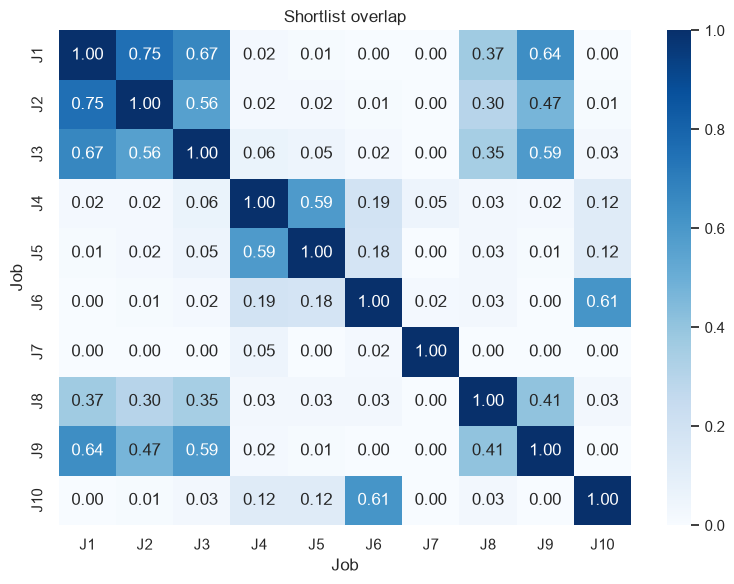

In [4]:
candidate_matrix = embedding_matrix(candidate_vectors)

def retrieve(k):
    k = min(k, len(candidate_vectors))
    if RETRIEVAL_BACKEND == "exact":
        indices, scores = exact_cosine_search(job_matrix, candidate_matrix, k)
        return {
            job_id: pd.DataFrame({
                "candidate_id": candidate_vectors.iloc[indices[row]].entity_id.to_numpy(),
                "retrieval_rank": np.arange(1, len(indices[row]) + 1),
                "embedding_similarity": scores[row],
            })
            for row, job_id in enumerate(selected_jobs.job_id)
        }
    if RETRIEVAL_BACKEND != "hnsw":
        raise ValueError("RETRIEVAL_BACKEND must be exact or hnsw")
    from index_hnsw import CachedOnlyEmbeddings
    from retrieval.vector_store import CandidateVectorStore
    load_dotenv(ROOT / ".env")
    url = os.getenv("RETRIEVAL_DATABASE_URL")
    if not url:
        raise ValueError("Set RETRIEVAL_DATABASE_URL for HNSW.")
    store = CandidateVectorStore(url, CachedOnlyEmbeddings(), dimension)
    try:
        store.connect()
        result = {}
        for row, job_id in enumerate(selected_jobs.job_id):
            matches = store.search_by_vector(job_matrix[row].tolist(), k)
            if not matches:
                raise ValueError(f"HNSW returned no candidates for {job_id}")
            result[job_id] = pd.DataFrame({
                "candidate_id": [m.candidate_id for m in matches],
                "retrieval_rank": [m.rank for m in matches],
                "embedding_similarity": [1 - m.distance for m in matches],
            })
        return result
    finally:
        store.close()

start = time.perf_counter()
shortlists = retrieve(INITIAL_K)
print(f"Retrieval batch elapsed: {time.perf_counter() - start:.3f}s")
ids = selected_jobs.job_id.tolist()
sets = [set(shortlists[job_id].candidate_id) for job_id in ids]
overlap = np.array([[len(a & b) / len(a | b) for b in sets] for a in sets])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(overlap, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="Blues",
            xticklabels=[labels[j] for j in ids], yticklabels=[labels[j] for j in ids], ax=ax)
ax.set(title="Shortlist overlap", xlabel="Job", ylabel="Job")
plt.tight_layout()
plt.show()

## 4. Performance scoring

LightGBM scores every retrieved pair using the same 19 features as training. The baseline needs no assignment history; it assumes interview and assessment scores are available. Missing those inputs would require a separate fallback.

The top five below are for inspection. All scored candidates remain available to allocation.

,name,current_title,retrieval_rank,performance_probability
0,Alex K. Hall,Psychiatric Mental Health Nurse Practitioner,21,59.3%
1,Marley P. Williams,Psychiatric Mental Health Nurse Practitioner,23,59.2%
2,Micah Cooper,Psychiatric Mental Health Nurse Practitioner,25,57.3%
3,Cameron Q. Miller,Psychiatric Mental Health Nurse Practitioner,31,56.6%
4,Adrian S. Bell,Clinical Behavior Analyst,33,55.4%


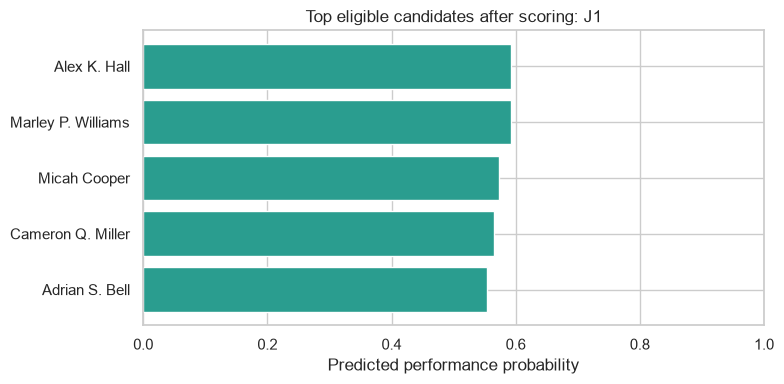

In [5]:
certifications = candidates.set_index("candidate_id").certifications
assert list(model.feature_name_) == BASE_FEATURE_COLUMNS

def score_shortlists(shortlists):
    frames = []
    for _, job in selected_jobs.iterrows():
        scored = rerank_candidates(job, shortlists[job.job_id], candidates, assessments,
                                  model, top_k=len(shortlists[job.job_id]))
        scored["job_id"] = job.job_id
        scored["eligible"] = scored.candidate_id.map(
            lambda cid: has_required_certifications(certifications.loc[cid], job.required_certifications))
        frames.append(scored)
    return pd.concat(frames, ignore_index=True)

pairs = score_shortlists(shortlists)
first_job = selected_jobs.job_id.iloc[0]
example = pairs.loc[(pairs.job_id == first_job) & pairs.eligible].head(5)
display(example[["name", "current_title", "retrieval_rank", "performance_probability"]]
        .style.format({"performance_probability": "{:.1%}"}))
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(example.name.iloc[::-1], example.performance_probability.iloc[::-1], color="#2a9d8f")
ax.set(xlim=(0, 1), xlabel="Predicted performance probability",
       title=f"Top eligible candidates after scoring: {labels[first_job]}")
plt.tight_layout()
plt.show()

### Model evaluation

These saved results use five-fold cross-validation grouped by job: validation jobs are excluded from each fold's training. Top-5 success is measured within the sampled labeled candidate pools, not across the full marketplace. Labels are simulated.

,Training pairs,Jobs,Features,Out-of-fold AUC,Out-of-fold Brier score
0,244938,2000,19,0.619169,0.236822


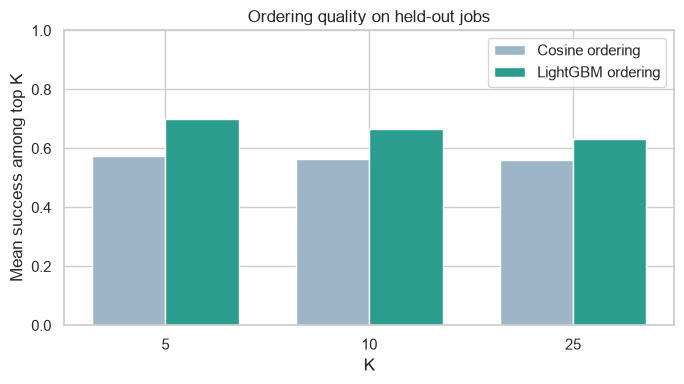

In [6]:
cv = json.loads((MODELING / "artifacts/model/cross_validation_report.json").read_text())
ranking = json.loads((MODELING / "artifacts/ranking_evaluation/summary.json").read_text())
display(pd.DataFrame([{
    "Training pairs": cv["rows"], "Jobs": cv["jobs"], "Features": cv["feature_count"],
    "Out-of-fold AUC": cv["overall_oof"]["roc_auc"],
    "Out-of-fold Brier score": cv["overall_oof"]["brier_score"],
}]))
cutoffs = sorted(ranking["cutoffs"], key=int)
x = np.arange(len(cutoffs))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - .18, [ranking["cutoffs"][k]["cosine_success_rate"] for k in cutoffs],
       width=.36, label="Cosine ordering", color="#9db6c7")
ax.bar(x + .18, [ranking["cutoffs"][k]["model_success_rate"] for k in cutoffs],
       width=.36, label="LightGBM ordering", color="#2a9d8f")
ax.set(xticks=x, xticklabels=cutoffs, ylim=(0, 1), xlabel="K",
       ylabel="Mean success among top K", title="Ordering quality on held-out jobs")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Allocation across jobs

Binary assignment variables enforce at most one job per candidate and one candidate per job. The linear optimizer first maximizes filled jobs, then maximizes total predicted success at that fill count.

An eligibility-only check finds the maximum possible fill count. Retrieval expands only if the current pool cannot reach it. A remaining vacancy is recorded explicitly.

In [7]:
pool = candidates.loc[candidates.candidate_id.isin(candidate_vectors.entity_id)]
maximum_fill, eligible_counts = full_pool_capacity(selected_jobs, pool)
print(f"Full candidate pool can fill {maximum_fill}/{len(selected_jobs)} jobs.")
k = min(INITIAL_K, len(candidate_vectors))
attempts = []
while True:
    optimal = optimize_allocation(pairs)
    attempts.append({"K": k, "filled": len(optimal), "maximum_fill": maximum_fill})
    if len(optimal) == maximum_fill or k == len(candidate_vectors):
        break
    k = min(k * 2, len(candidate_vectors))
    shortlists = retrieve(k)
    pairs = score_shortlists(shortlists)

greedy = greedy_allocate(pairs, require_all=False)
display(pd.DataFrame(attempts))
unfilled = selected_jobs.loc[~selected_jobs.job_id.isin(optimal.job_id), ["job_id", "title"]].copy()
unfilled["reason"] = unfilled.job_id.map(
    lambda jid: "No eligible candidate" if eligible_counts[jid] == 0 else
    ("Candidate capacity conflict" if len(optimal) == maximum_fill else "Retrieval did not reach feasible fill count"))
assert optimal.candidate_id.is_unique and optimal.job_id.is_unique
assert optimal.eligible.all()
if len(unfilled):
    display(unfilled)
else:
    print("All jobs filled.")

Full candidate pool can fill 10/10 jobs.


,K,filled,maximum_fill
0,50,10,10


All jobs filled.


### Greedy versus global assignment

Greedy processes jobs in job-ID order and chooses the best remaining candidate. The comparison uses the same final candidate pool. The totals below are sums of model estimates, not observed successes.

,Method,Filled jobs,Sum of predicted success
0,Greedy,10,6.538676
1,Global allocation,10,6.553335


,job,name_greedy,performance_probability_greedy,name_optimal,performance_probability_optimal
7,J10,Quinn T. Hill,0.696273,Sage N. Collins,0.641207
8,J6,Sage N. Collins,0.640680,Quinn T. Hill,0.710405


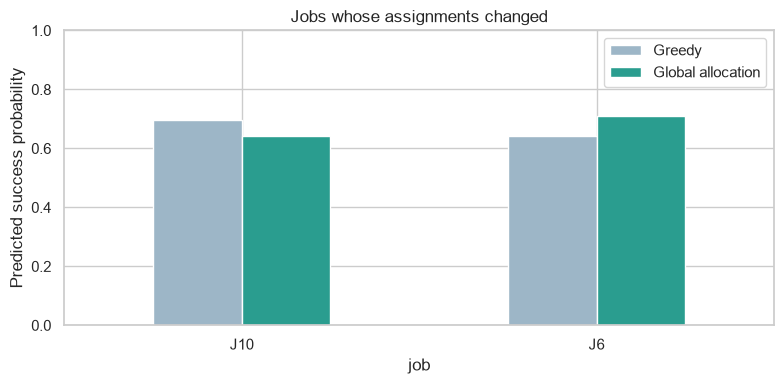

In [8]:
comparison = pd.DataFrame({
    "Method": ["Greedy", "Global allocation"],
    "Filled jobs": [len(greedy), len(optimal)],
    "Sum of predicted success": [greedy.performance_probability.sum(), optimal.performance_probability.sum()],
})
display(comparison)
changed = greedy[["job_id", "name", "candidate_id", "performance_probability"]].merge(
    optimal[["job_id", "name", "candidate_id", "performance_probability"]],
    on="job_id", how="outer", suffixes=("_greedy", "_optimal"))
changed = changed.loc[changed.candidate_id_greedy != changed.candidate_id_optimal].copy()
changed["job"] = changed.job_id.map(labels)
if len(changed):
    display(changed[["job", "name_greedy", "performance_probability_greedy",
                     "name_optimal", "performance_probability_optimal"]])
    plot = changed.set_index("job")[["performance_probability_greedy", "performance_probability_optimal"]]
    plot.columns = ["Greedy", "Global allocation"]
    ax = plot.plot.bar(figsize=(8, 4), color=["#9db6c7", "#2a9d8f"])
    ax.set(ylim=(0, 1), ylabel="Predicted success probability", title="Jobs whose assignments changed")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Both methods chose the same assignments for this batch.")

## 6. Final assignments

Each row is one assignment. Similarity explains retrieval; the performance score drives allocation. No historical-score blend is used in this walkthrough.

In [9]:
final = selected_jobs[["job_id", "title"]].merge(
    optimal[["job_id", "candidate_id", "name", "current_title", "retrieval_rank",
             "embedding_similarity", "performance_probability"]],
    on="job_id", how="left", validate="one_to_one")
final.insert(0, "job", final.job_id.map(labels))
final["status"] = np.where(final.candidate_id.notna(), "Assigned", "Unfilled")
display(final.style.format({"embedding_similarity": "{:.3f}",
                            "performance_probability": "{:.1%}"}, na_rep="—"))
print(f"{len(optimal)} assignments | {len(unfilled)} vacancies | final retrieval K={k}")

,job,job_id,title,candidate_id,name,current_title,retrieval_rank,embedding_similarity,performance_probability,status
0,J1,3884426762,PRN Registered Nurse,syn_v1_004854,Alex K. Hall,Psychiatric Mental Health Nurse Practitioner,21,0.529,59.3%,Assigned
1,J2,3901937580,Registered Nurse I (Nights),syn_v1_004210,Adrian S. Bell,Clinical Behavior Analyst,10,0.526,58.8%,Assigned
2,J3,3891074610,Team Nurse - Agency Only,syn_v1_002177,Noel N. Adams,Psychiatric Mental Health Nurse Practitioner,46,0.579,66.5%,Assigned
3,J4,3905261467,Licensed Practical Nurse - Primary Care PACT - UP TO 10k SIGN ON BONUS,syn_v1_003599,Cameron K. Reed,Registered Nurse,37,0.548,70.5%,Assigned
4,J5,3889279489,Licensed Practical Nurse (LPN),syn_v1_003679,Lane E. Evans,LTAC Registered Nurse,28,0.581,81.7%,Assigned
5,J6,3904719931,"Assistant Nurse Manager, Day Shift, Rehabilitation",syn_v1_004380,Quinn T. Hill,LTAC Registered Nurse,35,0.573,71.0%,Assigned
6,J7,3902358712,Nurse (SANE) - Outpatient,syn_v1_002597,Avery Z. Clark,Patient Care Technician,20,0.536,59.6%,Assigned
7,J8,3900955065,REGISTERED NURSE - **La Selva Residential**,syn_v1_002851,Sam A. Clark,Nurse Practitioner,47,0.599,54.1%,Assigned
8,J9,3889290143,Certified Registered Nurse Practitioner - Warren State Hospital,syn_v1_000365,Casey J. Walker,Psychiatric Mental Health Nurse Practitioner,25,0.615,69.6%,Assigned
9,J10,3903843291,"Registered Nurse (RN), Night Shift, Acute-Care Rehab",syn_v1_003908,Sage N. Collins,Travel Registered Nurse,35,0.608,64.1%,Assigned


10 assignments | 0 vacancies | final retrieval K=50


The demo assumes candidates are available for one assignment in this batch. Certification matching uses the structured fields. Acceptance/conversion and delayed feedback are not modeled here. The saved evaluation reports describe synthetic labels; fresh JDs have predictions only.

Related code: [retrieval](../retrieval/src/retrieval/), [features and reranking](../modeling/src/modeling/), [allocation](../allocation/src/allocation/).